<a href="https://colab.research.google.com/github/davidsjohnson/xai_ac_wise25/blob/main/notebooks/exercise4b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# XAI for Affective Computing (WiSe2025)
# Exercise 4b: Explanations in the Audio Domain - Explaining Speech Emotion Recognition

In this notebook you will attempt to explanations of a speech emotion recognition (SER) task using tabular data and a XGBoost classifier and spectrograms with a CNN. Both datasets and models are provided in the notebook below. 

To use this notebook, please make sure to go step by step through each of the cells review the code and comments along the way.

This notebook builds on the methods learned in previous notebooks, so will not be as guided as the previous exercises.

***NOTE**: This notebook runtime could be improved by using a GPU if available.*

## Notebook Setup

Make sure to uncomment code based on if you are running locally or via Google Colab

In [1]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

In [ ]:
if IN_COLAB:
  !git clone https://github.com/davidsjohnson/xai_ac_wise25.git

In [ ]:
import sys
import os

if IN_COLAB:
  sys.path.append(os.path.realpath('xai_ac_wise25'))
else:
  sys.path.append(os.path.realpath('../'))

In [4]:
from pathlib import Path

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn.functional as F
import torch.nn as nn

import librosa
import librosa.display

import matplotlib.pyplot as plt

from IPython.display import Audio
import IPython

import utils
import models
import evaluate

In [5]:
base_dir = Path('../data/') if not IN_COLAB else Path('xai_ac_wise25/data/')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


## Setup Datasets

### Download Data and Extract Features

First we need to load our datast.  For this task, we will be using the audio portion of the [Ravdess dataset](https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio).  

For the tabular dataset, we provide you with preextracted features in the form of a pandas dataframe.  Tabular features were extracted with the [openSmile](https://audeering.github.io/opensmile-python/) package using the [Extended Geneva Minimalistic Acoustic Parameter
Set (EGeMAPS)](https://mediatum.ub.tum.de/doc/1523509/file.pdf). Please have a look at the paper for a detailed explanation of the different features.

We will also extract Spectrograms from the audio clips using librosa.

We are also providing 300 audio clips of the test dataset containing actors \[15,  8, 20, 11,  5\]

In [8]:
ravdess_link = 'https://zenodo.org/record/1188976/files/Audio_Speech_Actors_01-24.zip?download=1'
data_dir = utils.download_file(url=ravdess_link,
                               file_name="ravdess.zip",
                               cache_dir= base_dir / 'ravdess',
                               extract=True,
                               force_download=False,
                               archive_folder='')
data_dir

File downloaded to: ../data/ravdess/ravdess.zip


PosixPath('../data/ravdess')

### Load the RAVDESS extracted Features

In [ ]:
LABEL_DICT = {0:'neutral', 1:'calm', 2:'happy', 3:'sad', 4:'angry', 5:'fear', 6:'disgust', 7:'surprise'}
LABEL_MAP_DICT = {v: k for k, v in LABEL_DICT.items()}
LABELS = list(LABEL_DICT.values())

# load dataframes from CSV
# contains features extracted with OpenSMILE (eGEMAPS feature set)
df_train = pd.read_csv(base_dir / 'ravdess_features/radvess_opensmile_train.csv')
df_test = pd.read_csv(base_dir / 'ravdess_features/radvess_opensmile_test.csv')

# update audio_paths to match new locations
audio_path = base_dir / 'ravdess_audioclips'
def update_paths(row):
    return str(audio_path / Path(row.path).name)
df_train.path = df_train.apply(update_paths, axis='columns')
df_test.path = df_test.apply(update_paths, axis='columns')

# get feature columns
feature_names = list(df_train.columns[6:])
print(feature_names)

['F0semitoneFrom27.5Hz_sma3nz_amean', 'F0semitoneFrom27.5Hz_sma3nz_stddevNorm', 'F0semitoneFrom27.5Hz_sma3nz_percentile20.0', 'F0semitoneFrom27.5Hz_sma3nz_percentile50.0', 'F0semitoneFrom27.5Hz_sma3nz_percentile80.0', 'F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2', 'F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope', 'F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope', 'F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope', 'F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope', 'loudness_sma3_amean', 'loudness_sma3_stddevNorm', 'loudness_sma3_percentile20.0', 'loudness_sma3_percentile50.0', 'loudness_sma3_percentile80.0', 'loudness_sma3_pctlrange0-2', 'loudness_sma3_meanRisingSlope', 'loudness_sma3_stddevRisingSlope', 'loudness_sma3_meanFallingSlope', 'loudness_sma3_stddevFallingSlope', 'spectralFlux_sma3_amean', 'spectralFlux_sma3_stddevNorm', 'mfcc1_sma3_amean', 'mfcc1_sma3_stddevNorm', 'mfcc2_sma3_amean', 'mfcc2_sma3_stddevNorm', 'mfcc3_sma3_amean', 'mfcc3_sma3_stddevNorm', 'mfcc4_sma3_amean', 'mfcc4_sma3_std

### Review the Extracted Features

In [12]:
# review a random sample of the training data
df_train.sample(5)

,Unnamed: 0,actor,emotion,intensity,path,emotion_label,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_percentile20.0,F0semitoneFrom27.5Hz_sma3nz_percentile50.0,...,slopeUV0-500_sma3nz_amean,slopeUV500-1500_sma3nz_amean,spectralFluxUV_sma3nz_amean,loudnessPeaksPerSec,VoicedSegmentsPerSec,MeanVoicedSegmentLengthSec,StddevVoicedSegmentLengthSec,MeanUnvoicedSegmentLength,StddevUnvoicedSegmentLength,equivalentSoundLevel_dBp
163,163,7,2,2,../data/ravdess_audioclips/03-01-03-02-02-02-0...,happy,35.832840,0.176464,35.913151,38.118954,...,-0.024181,0.001954,0.071422,2.094241,1.591512,0.265000,0.235354,0.292857,0.369467,-29.148167
33,33,9,3,2,../data/ravdess_audioclips/03-01-04-02-01-01-0...,sad,24.048866,0.135277,22.307709,23.246054,...,0.045890,0.006331,0.010695,2.806123,2.325582,0.091111,0.041485,0.288000,0.379125,-55.951122
285,285,13,7,1,../data/ravdess_audioclips/03-01-08-01-02-02-1...,surprise,33.905399,0.145594,31.611668,34.923592,...,0.017449,0.008417,0.003229,2.317881,0.673401,0.500000,0.160000,0.640000,0.431354,-44.590839
965,1025,3,0,1,../data/ravdess_audioclips/03-01-01-01-02-01-0...,neutral,27.724579,0.127101,25.141756,28.601555,...,0.060953,0.007959,0.015510,2.005731,1.162791,0.275000,0.217428,0.450000,0.463508,-42.946384
355,355,22,6,2,../data/ravdess_audioclips/03-01-07-02-01-01-2...,disgust,34.065750,0.068348,31.847136,34.461617,...,0.060831,0.006241,0.022157,1.895735,0.959233,0.400000,0.268608,0.496000,0.442339,-39.346222


In [13]:
# review the extracted features

audio_sample = df_test.sample(1)
audio_sample

,Unnamed: 0,actor,emotion,intensity,path,emotion_label,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_percentile20.0,F0semitoneFrom27.5Hz_sma3nz_percentile50.0,...,slopeUV0-500_sma3nz_amean,slopeUV500-1500_sma3nz_amean,spectralFluxUV_sma3nz_amean,loudnessPeaksPerSec,VoicedSegmentsPerSec,MeanVoicedSegmentLengthSec,StddevVoicedSegmentLengthSec,MeanUnvoicedSegmentLength,StddevUnvoicedSegmentLength,equivalentSoundLevel_dBp
69,1089,20,4,2,../data/ravdess_audioclips/03-01-05-02-01-01-2...,angry,37.578888,0.209819,31.989334,37.524464,...,0.051881,0.003812,0.102346,1.941748,1.965602,0.2075,0.19136,0.27875,0.35105,-29.327112


In [14]:
# Display Audio to list to
Audio(audio_sample['path'].values[0])

In [10]:
# basepath = Path('./output')

# output_path = basepath / 'ravdess'
# feature_path = output_path / 'features'
# audio_path = output_path / 'audio_clips'
# model_path = output_path /'model'

# os.makedirs(feature_path, exist_ok=True)
# os.makedirs(audio_path, exist_ok=True)

### Extract Spectrograms

In [15]:
def get_log_melspec(data, sample_rate, silence_thresh=25):
  """
  Function for extracting features from an audio sample.  The audio is preprocess to remove silence and then
  padded on both sides to ensure each clip is 5 seconds.
  Then the log mel spectrogram is extracted.
  """
  trimmed, _ = librosa.effects.trim(data, top_db=silence_thresh)
  padded = np.pad(trimmed, (int(sample_rate*2.5-len(trimmed)//2), int(sample_rate*2.5-len(trimmed)//2)), 'constant')
  mel = librosa.feature.melspectrogram(y=padded, sr=sample_rate, n_fft=2048, hop_length=512, n_mels=128)
  return librosa.power_to_db(mel, ref=np.max)

In [16]:
# setup dictionary to store data
data = dict(
    actor = [],
    emotion = [],
    intensity = [],
    gender = [],
    path = []
)

# final all wave files
wav_files = data_dir.rglob('*.wav')

# process each file
for wav in wav_files:

    # extract details from filename (see zenodo page for details)
    _, _, emo, emo_int, _, _, actor = wav.stem.split('-')

    data['actor'].append(int(actor))
    data['emotion'].append(int(emo)-1)
    data['intensity'].append(int(emo_int))
    data['gender'].append('male' if int(actor) % 2 == 0 else 'female')
    data['path'].append(str(wav))

df_rav = pd.DataFrame.from_dict(data)
df_rav['emotion_label'] = df_rav.emotion.replace(LABEL_DICT, inplace=False)

# extract features and save to dataframe
def load_melspec(row):
  a, sr = librosa.load(row['path'], sr=16000)
  return get_log_melspec(a, sr, silence_thresh=55)

df_rav['spectro'] = df_rav.apply(load_melspec, axis=1)

/Users/djohnson/teaching/xai_ac_sose25/.venv/lib/python3.10/site-packages/numba/cpython/hashing.py:524: UserWarning: FNV hashing is not implemented in Numba. See PEP 456 https://www.python.org/dev/peps/pep-0456/ for rationale over not using FNV. Numba will continue to work, but hashes for built in types will be computed using siphash24. This will permit e.g. dictionaries to continue to behave as expected, however anything relying on the value of the hash opposed to hash as a derived property is likely to not work as expected.
  warnings.warn(msg)


In [17]:
# validate extracted features
for idx, row in df_rav.iterrows():
  assert row.spectro.shape == (128, 157), f'shape: {row.spectro.shape}'

### Review the Spectrogram Data

In [18]:
# review one row
audio_sample = df_rav.sample(1)
audio_sample

,actor,emotion,intensity,gender,path,emotion_label,spectro
124,18,0,1,male,../data/ravdess/Actor_18/03-01-01-01-01-02-18.wav,neutral,"[[-80.0, -80.0, -80.0, -80.0, -80.0, -80.0, -8..."


In [19]:
# Display Audio to list to
Audio(audio_sample['path'].values[0])

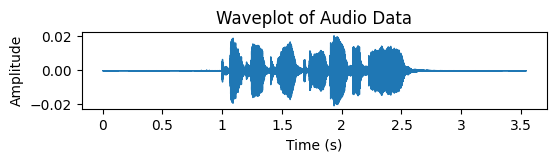

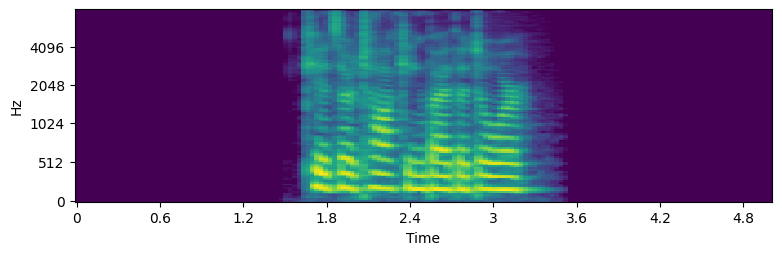

In [20]:
# load audio and downsample to 16000
y, sr = librosa.load(audio_sample['path'].values[0], sr=16000)

# Create wave plot
plt.figure(figsize=(6, 1))
librosa.display.waveshow(y, sr=sr)
plt.title('Waveplot of Audio Data')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()

plt.figure(figsize=(9,2.5))
librosa.display.specshow(audio_sample['spectro'].values[0],
                         sr=sr, hop_length=512, n_fft=2048,
                         x_axis='time', y_axis='mel',
                         cmap = 'viridis'
                         )
plt.show()

## Setup and Review the Tabular Model

### Train an XGBoost Model

Now we train an XGBoost model to perform explanations.  The model should get $100\%$ on the training data.

In [6]:
from xgboost import XGBClassifier

In [22]:
random_state = 24

xgb = XGBClassifier(n_estimators=20, 
                    max_depth=15,
                    learning_rate=0.1, 
                    objective='binary:logistic',
                    random_state=random_state)

xgb.fit(df_train[feature_names], df_train['emotion'])
score = xgb.score(df_train[feature_names], df_train['emotion'])
print(f'Train Accuracy: {score*100:.2f}%')

Train Accuracy: 100.00%


### Evaluate the model

Now let's evaluate the performance of the RDF Classifier on the `X_aus` dataset. The accuracy should be around $45.67\%$, indicating significant overfitting. However, it is much better than random guessing at $12.5\%$

We should also generate the predictions of the model for the dataset, and store them in the dataframe.

In [23]:
score = xgb.score(df_test[feature_names], df_test['emotion'])
print(f'Test Accuracy: {score*100:.2f}%')

# generate predictions for later user
df_test['emotion_pred'] = xgb.predict(df_test[feature_names])
(df_test['emotion_pred'] == df_test['emotion']).mean()

Test Accuracy: 45.67%


0.45666666666666667

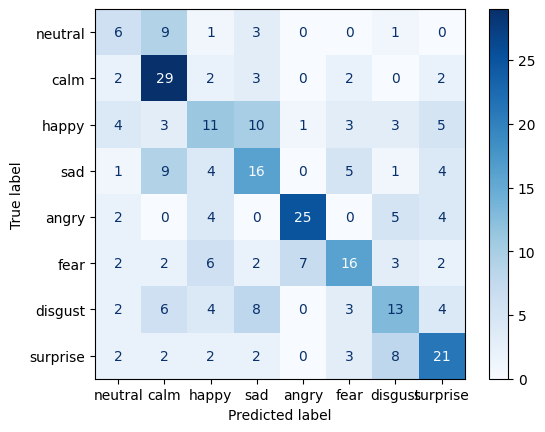

In [24]:
cm = confusion_matrix(df_test['emotion'], df_test['emotion_pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
disp.plot(cmap='Blues')
plt.grid(False)

#### Review some predictions

In [25]:
audio_samples = df_test.sample(5)
for idx, sample in audio_samples.iterrows():
    print(f'Index: {idx} - Emotion: {sample.emotion_label} | Prediction: {LABELS[sample.emotion_pred]}')
    print(sample.path)
    IPython.display.display(IPython.display.Audio(sample.path))

Index: 110 - Emotion: calm | Prediction: calm
../data/ravdess_audioclips/03-01-02-02-01-01-20.wav


Index: 121 - Emotion: surprise | Prediction: surprise
../data/ravdess_audioclips/03-01-08-02-02-02-11.wav


Index: 156 - Emotion: happy | Prediction: neutral
../data/ravdess_audioclips/03-01-03-02-02-02-11.wav


Index: 74 - Emotion: fear | Prediction: calm
../data/ravdess_audioclips/03-01-06-01-01-01-20.wav


Index: 65 - Emotion: calm | Prediction: surprise
../data/ravdess_audioclips/03-01-02-02-02-02-20.wav


## Setup and Review the CNN Model

### Setup Data Loaders

In [22]:
# # split dataset by actors
# all_actors = df_rav['actor'].unique()
# actors_gender = df_rav.groupby('actor')['gender'].unique().reset_index()

# train_actors, tmp = train_test_split(actors_gender, train_size=10, stratify=actors_gender['gender'], random_state=36851234)
# val_actors, test_actors = train_test_split(tmp, train_size=8, stratify=tmp['gender'], random_state=36851234)

# train_actors = train_actors['actor'].tolist()
# val_actors = val_actors['actor'].tolist()
# test_actors = test_actors['actor'].tolist()

# df_train = df_rav[df_rav['actor'].isin(train_actors)]
# df_val = df_rav[df_rav['actor'].isin(val_actors)]
# df_test = df_rav[df_rav['actor'].isin(test_actors)]

In [28]:
# dv_rav contains the full dataset of spectrograms for all speakers.
# For this tutorial we will do a random data set split, but a more robust approach would be to split by speaker (see above cell)
df_train_cnn = df_rav.sample(frac=.8, random_state=0)
df_val_cnn = df_rav.drop(df_train_cnn.index).sample(frac=.5, random_state=0)
df_test_cnn = df_rav.drop(df_train_cnn.index).drop(df_val_cnn.index)

In [29]:
def get_dataset(df, feats_col, labels_col):
  labels = df[labels_col].values

  # convert from object array in dataframe to floats
  # and convert to numpy array
  feats = df[feats_col]
  feats = [f.astype(float) for f in feats]
  feats = np.array(feats)
  feats = feats[:, None, :, :]

  idxs = df.index.values

  # Setup features and labels as tensors
  X = torch.tensor(feats, dtype=torch.float32)
  y = torch.tensor(labels, dtype=torch.long)
  idxs = torch.tensor(idxs, dtype=torch.long)

  # Create TensorDataset
  dataset = TensorDataset(X, y, idxs)

  return dataset

In [30]:
# setup dataloaders based on previous dataset split
ds_train = get_dataset(df_train_cnn, 'spectro', 'emotion')
ds_val = get_dataset(df_val_cnn, 'spectro', 'emotion')
ds_test = get_dataset(df_test_cnn, 'spectro', 'emotion')

dl_train = DataLoader(ds_train, batch_size=64, shuffle=True)
dl_val = DataLoader(ds_val, batch_size=1, shuffle=False)
dl_test = DataLoader(ds_test, batch_size=1, shuffle=False)

### Load Pretrained Model

In [31]:
# get checkpoint
ckpt_link = 'https://uni-bielefeld.sciebo.de/s/eiOiBrhuOENmo0p/download'
ckpt_path = utils.download_file(ckpt_link,
                                'ravdess_model.pth',
                                cache_dir='./data/ravdess/model',
                                extract=False,
                                force_download=False
                                )
ckpt_path

File downloaded to: data/ravdess/model/ravdess_model.pth


PosixPath('data/ravdess/model/ravdess_model.pth')

In [32]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [33]:
# To load the best model:
model = models.ResNet(len(LABELS))
model.load_state_dict(torch.load(ckpt_path, map_location='cpu'))
model.to(device);

### Evaluate Model

Next we will evaluate the loaded model to ensure it is working as expected.  You should get around $92.36\%$ accurac on the test set. The accuracy is high, because the model was not split between actors as we did in the previous example

In [34]:
evaluate.evaluate_model(model, dl_train, criterion, device)
evaluate.evaluate_model(model, dl_val, criterion, device)
_, _, test_preds, test_probs = evaluate.evaluate_model(model, dl_test, criterion, device)

Evaluation Loss: 0.2378, Evaluation Accuracy: 0.9349
Evaluation Loss: 0.0925, Evaluation Accuracy: 0.9792
Evaluation Loss: 0.1880, Evaluation Accuracy: 0.9236


In [35]:
# load probabilities and predictions into dataframe for test dataset
df_test_cnn['emotion_pred'] = test_preds
(df_test_cnn['emotion'] == df_test_cnn['emotion_pred']).mean()

0.9236111111111112

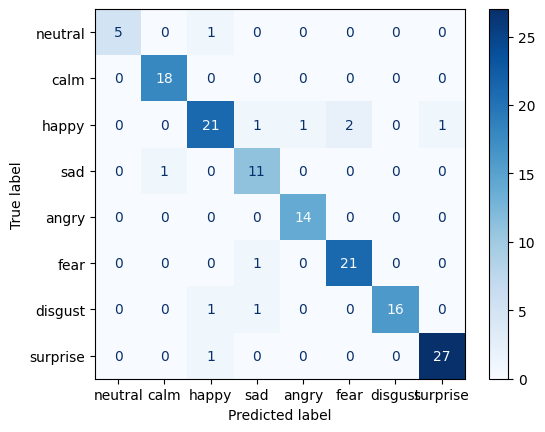

In [36]:
cm = confusion_matrix(df_test_cnn['emotion'], df_test_cnn['emotion_pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
disp.plot(cmap='Blues')
plt.grid(False)

#### Review some predictions

In [37]:
audio_samples = df_test_cnn.sample(5)
for idx, sample in audio_samples.iterrows():
    print(f'Index: {idx} - Emotion: {sample.emotion_label} | Prediction: {LABELS[sample.emotion_pred]}')
    print(sample.path)
    IPython.display.display(IPython.display.Audio(sample.path))

Index: 705 - Emotion: happy | Prediction: angry
../data/ravdess/Actor_05/03-01-03-02-01-02-05.wav


Index: 1155 - Emotion: happy | Prediction: happy
../data/ravdess/Actor_09/03-01-03-02-02-01-09.wav


Index: 599 - Emotion: calm | Prediction: calm
../data/ravdess/Actor_03/03-01-02-01-01-01-03.wav


Index: 812 - Emotion: calm | Prediction: calm
../data/ravdess/Actor_15/03-01-02-02-01-02-15.wav


Index: 1307 - Emotion: calm | Prediction: calm
../data/ravdess/Actor_06/03-01-02-02-02-01-06.wav


## Generate Explanations

### Task 1 - Implement Global Explanations for Tabular Data

Choose a global explanation method from the previous notebooks or any other approach of your choosing. Then implement it to generate global explanations for the tabular audio data. 

Then answer the questions below.


In [ ]:
###### Enter your Code Below ######
##################################


#### Task 1. Questions

1. Which method did you choose and why?
2. Select 2 of the emotions available in the RAVDESS dataset, which are the most important features for this model? Do these features align with the literature on speech characteristics for these emotions?

Write your answers here...

### Task 2 - Implement Local Explanations for Tabular Data

Choose a local explanation method from the previous notebooks or any other approach of your choosing. Then implement it to generate locals explanations for the tabular audio data. Make sure to select multiple audio examples from different classes to better explore the explanations. And include the audio with the explanations so that you can listen along.  The follow code snippet will help: `IPython.display.display(IPython.display.Audio(<AUDIOFILE_PATH>))`

Then answer the questions below.

In [38]:
###### Enter your Code Below ######
##################################


#### Task 2. Questions

1. Which method did you choose and why?
2. Do the explanations align with the global explanations from the previous task?
2. Do the explanations help you understand why a correct or incorrect decicions was made? Why or why not?

Write your answers here...

### Task 3 - Implment Local Explanations for Spectrogram Data

In [ ]:
###### Enter your Code Below ######
##################################


#### Task 3. Questions

1. Which method did you choose and why?
2. What are the main challenges with this type of explanation for audio data?
3. What would be a better approach for explaining this type of data from the methods that we have explored this semester?

Write your answers here...